# Interpretação do modelo treinado (XGBoost)

In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import shap
from train import Log1pColumns, merge_data

Inicialmente, vamos:
- Carregar o modelo
- Carregar os datasets e fazer seu merge

In [3]:
# carrega o modelo
loaded_model = joblib.load('../models/XGBoost_model.joblib')

# carrega os datasets
dfh = pd.read_csv('../data/kc_house_data.csv')
dfz = pd.read_csv('../data/zipcode_demographics.csv')

# faz o merge dos dados e separa a variável alvo das features
df = merge_data(dfh, dfz)
X = df.drop(columns=['price'])
y = df['price']

# extrai o nome das features, pega o pipeline e o modelo em si
feature_names = X.columns.tolist()
pipeline = loaded_model['model']
core_model = pipeline.named_steps['model'].regressor_

# Feature Importance

In [4]:
# Recupera o dicionário de importância das features do modelo XGBoost.
# Aqui usamos `importance_type='gain'` para obter a média do ganho de cada split
# que usou a feature (uma medida comum de importância).
score = core_model.get_booster().get_score(importance_type='gain')

# cria um df das features e seus scores (valor de importância)
rows = []
for i, name in enumerate(feature_names):
    rows.append({
        'feature': name,
        'importance': score.get(name, 0.0)
    })

importance_df = pd.DataFrame(rows).sort_values('importance', ascending=False).reset_index(drop=True)
importance_df.head(10)

,feature,importance
0,per_bchlr,39.105324
1,per_prfsnl,20.115664
2,grade,18.923775
3,sqft_living,12.640376
4,view,7.325098
5,sqft_above,5.796853
6,lat,5.035030
7,sqft_living15,4.466350
8,waterfront,3.562164
9,medn_incm_per_prsn_amt,2.568623


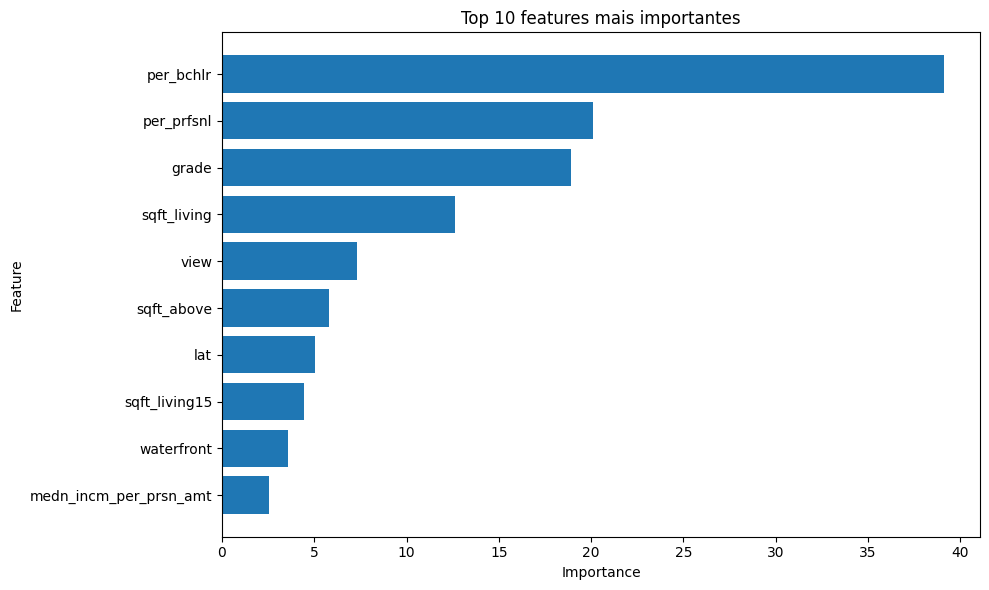

In [5]:
top_imp = importance_df.head(10).sort_index(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(top_imp['feature'], top_imp['importance'])
plt.title(f'Top 10 features mais importantes')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# SHAP

In [6]:
# cria um shap explainer que ajuda a decompor a predição por features
explainer = shap.Explainer(core_model)

# Calcula os valores SHAP para o dataset
shap_values = explainer(X)

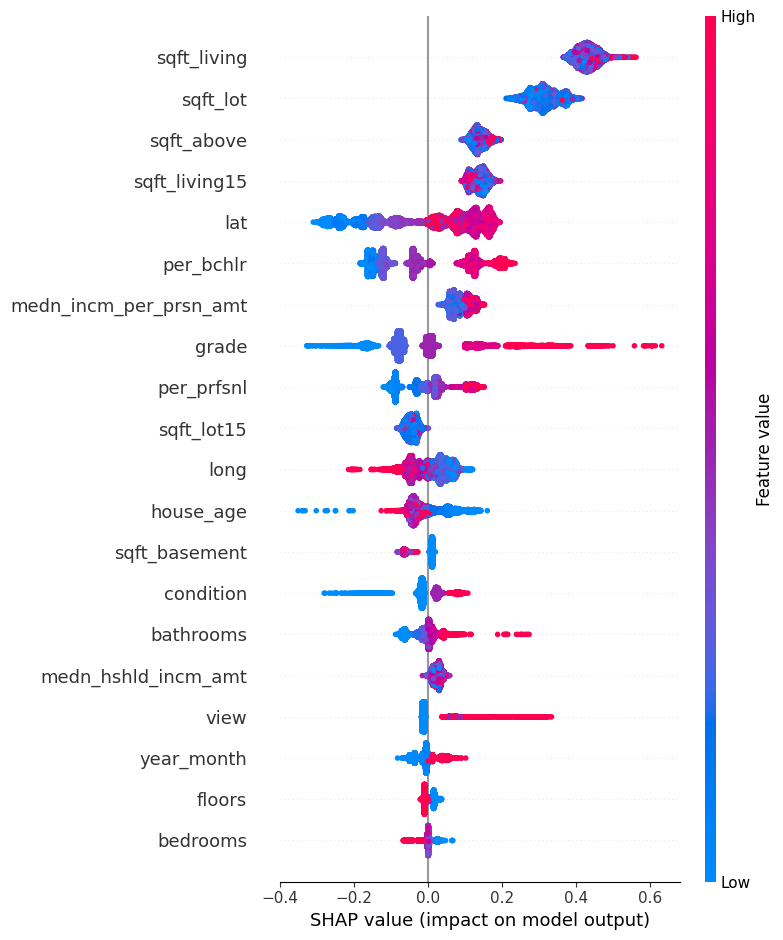

In [7]:
# o plot mostra o impacto de cada feature na predição e a distruição dos valores shap
shap.summary_plot(shap_values, X)

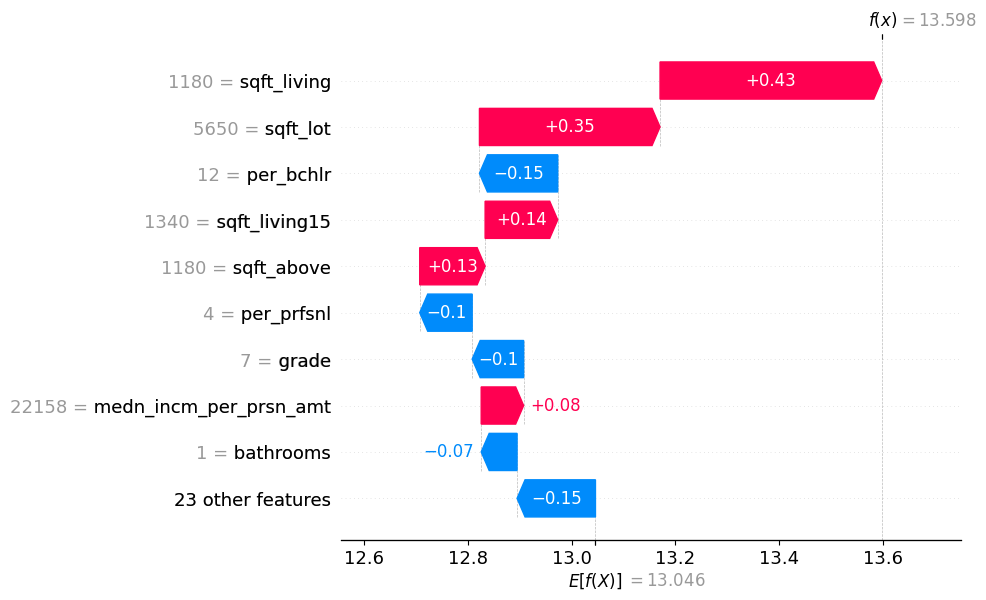

In [8]:
# explica como cada feature contribuiu para a predição
shap.plots.waterfall(shap_values[0])